# Étude complète d’un matériau cristallin
Notebook structuré selon les consignes du projet.

Remplacer `MATERIAL_NAME` par le matériau attribué.

## 1. Téléchargement de la structure cristalline

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pymatgen as mg

from pymatgen.electronic_structure.plotter import BSPlotter
from pymatgen.phonon.plotter import PhononBSPlotter

#import pour l'affichage des opérations de symétrie
from jupyter_jsmol.pymatgen import quick_view
from jupyter_jsmol.pymatgen import JsmolView
from pymatgen.io.cif import CifWriter
import plotly.graph_objects as go
from IPython.display import display





#import pymatviz as pv
# Exemple avec pymatgen (Materials Project)
#from mp_api.client import MPRester
from pymatgen.ext.matproj import MPRester  #j'ai mis celui l'autre import ne marche sur mon vscode 
from mp_api.client import MPRester



API_KEY = "qda0IS7aXwuItxSu10vk1FkNoy8UZQiX"
material_id = "mp-1378"  #id du LiC dans material project 

with MPRester(API_KEY) as mpr:
    structure = mpr.get_structure_by_material_id(material_id)

    structure.to(fmt="cif", filename="LiC.cif")

structure






Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Structure Summary
Lattice
    abc : 3.591529777348829 4.011704109915074 4.011704492667927
 angles : 73.52458272493287 63.408171496645096 63.40816766642372
 volume : 45.96833740475323
      A : np.float64(3.20947838) np.float64(0.0) np.float64(1.61193507)
      B : np.float64(1.4266634900000001) np.float64(3.56532885) np.float64(1.16053063)
      C : np.float64(-0.0052797) np.float64(-0.023513299999999) np.float64(4.01163211)
    pbc : True True True
PeriodicSite: Li (3.492, 2.618, 5.05) [0.7607, 0.7393, 0.7393]
PeriodicSite: Li (1.139, 0.9233, 1.734) [0.2393, 0.2607, 0.2607]
PeriodicSite: C (1.24, 3.098, 1.532) [0.0, 0.8697, 0.1303]
PeriodicSite: C (0.1812, 0.444, 3.64) [-0.0, 0.1303, 0.8697]

Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Nombres d'atomes dans la maille : 8


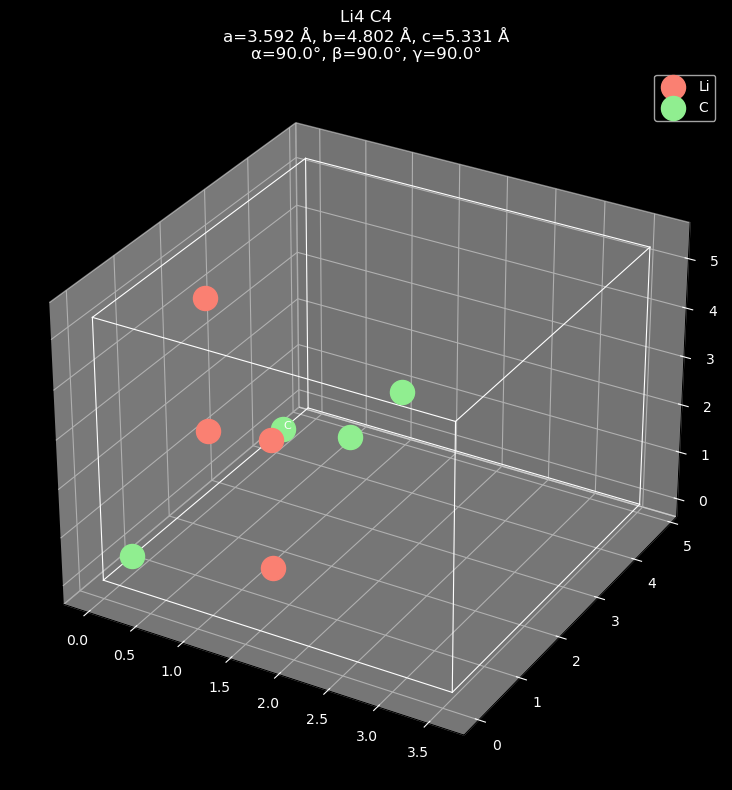

In [2]:

with MPRester(API_KEY) as mpr:
    structure = mpr.get_structure_by_material_id(material_id,conventional_unit_cell=True)

print(f"Nombres d'atomes dans la maille : {len(structure.sites)}")
couleurs = {"Li": "salmon", "C": "lightgreen"}

fig = plt.figure(figsize=(8, 8), facecolor="black")
ax = fig.add_subplot(111, projection="3d")
ax.set_facecolor("black")

# Tracer les atomes
for site in structure.sites:
    x, y, z = site.coords
    elem = site.species_string
    ax.scatter(x, y, z,
               color=couleurs.get(elem, "white"),
               s=300,
               label=elem)
    ax.text(x, y, z, elem, color="white", fontsize=8)

# Tracer les arêtes de la maille
from itertools import combinations


lattice = structure.lattice.matrix
origin = np.array([0, 0, 0])
vecs = [lattice[0], lattice[1], lattice[2]]

# 12 arêtes de la maille
edges = [
    (origin, vecs[0]),
    (origin, vecs[1]),
    (origin, vecs[2]),
    (vecs[0], vecs[0]+vecs[1]),
    (vecs[0], vecs[0]+vecs[2]),
    (vecs[1], vecs[1]+vecs[0]),
    (vecs[1], vecs[1]+vecs[2]),
    (vecs[2], vecs[2]+vecs[0]),
    (vecs[2], vecs[2]+vecs[1]),
    (vecs[0]+vecs[1], vecs[0]+vecs[1]+vecs[2]),
    (vecs[0]+vecs[2], vecs[0]+vecs[1]+vecs[2]),
    (vecs[1]+vecs[2], vecs[0]+vecs[1]+vecs[2]),
]

for start, end in edges:
    ax.plot(*zip(start, end), color="white", linewidth=0.8)

# Infos maille
lattice_params = structure.lattice
ax.set_title(
    f"{structure.formula}\n"
    f"a={lattice_params.a:.3f} Å, b={lattice_params.b:.3f} Å, c={lattice_params.c:.3f} Å\n"
    f"α={lattice_params.alpha:.1f}°, β={lattice_params.beta:.1f}°, γ={lattice_params.gamma:.1f}°",
    color="white"
)

# Légende sans doublons
handles, labels_legend = ax.get_legend_handles_labels()
unique = dict(zip(labels_legend, handles))
ax.legend(unique.values(), unique.keys(), facecolor="black", labelcolor="white")

ax.tick_params(colors="white")
plt.tight_layout()
plt.show()


## 2. Réseau direct et réciproque

In [3]:
lattice = structure.lattice
a1, a2, a3 = lattice.matrix
reciprocal_lattice = lattice.reciprocal_lattice.matrix

print("Vecteurs réseau direct:")
print(a1, a2, a3)

print("Vecteurs réseau réciproque:")
print(reciprocal_lattice)

# #représentation des réseaux
# # reseau direct
#fig = plt.figure()
#ax = fig.add_subplot(111, projection='3d')

# # Origine
#origin = [0, 0, 0]

# # Tracé des vecteurs
#ax.quiver(*origin, *a1, length=1, normalize=False)
#ax.quiver(*origin, *a2, length=1, normalize=False)
#ax.quiver(*origin, *a3, length=1, normalize=False)

# # Labels
#ax.text(*a1, "a1")
#ax.text(*a2, "a2")
#ax.text(*a3, "a3")

#ax.set_xlabel("X")
#ax.set_ylabel("Y")
#ax.set_zlabel("Z")

#plt.show()

# # reseau reciproque
# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')
# # Tracé des vecteurs
# ax.quiver(*origin, *reciprocal_lattice[0], length=1, normalize=False)
# ax.quiver(*origin, *reciprocal_lattice[1], length=1, normalize=False)
# ax.quiver(*origin, *reciprocal_lattice[2], length=1, normalize=False)

# # Labels
# ax.text(*reciprocal_lattice[0], "b1")
# ax.text(*reciprocal_lattice[1], "b2")
# ax.text(*reciprocal_lattice[2], "b3")

# ax.set_xlabel("X")
# ax.set_ylabel("Y")
# ax.set_zlabel("Z")

# plt.show()


Vecteurs réseau direct:
[3.59152978e+00 0.00000000e+00 2.19917772e-16] [7.72217565e-16 4.80198177e+00 2.94036580e-16] [0.         0.         5.33075611]
Vecteurs réseau réciproque:
[[ 1.74944542e+00 -2.81332280e-16  0.00000000e+00]
 [ 0.00000000e+00  1.30845672e+00  0.00000000e+00]
 [-7.21725269e-17 -7.21725269e-17  1.17866681e+00]]


## 3. Type de maille, système cristallin, groupe ponctuel

In [4]:
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
sga = SpacegroupAnalyzer(structure)

print("Système cristallin:", sga.get_crystal_system())
print("Type de maille:", sga.get_lattice_type())
print("Groupe ponctuel:", sga.get_space_group_symbol())

Système cristallin: orthorhombic
Type de maille: orthorhombic
Groupe ponctuel: Immm


## 4. Application de trois éléments de symétrie

Pour les systèmes orthorhombiques, les trois caractères décrivent la 
symétrie le long des trois axes, a, b, et c.
Groupe ponctuel: mmm 
ici on nous dit qu'il y a des symétries le long des trois axes (1)
première dircetion de symétrie : 
maille conventionnelle est orthorhombic

Le système orthorhombique possède trois directions de symétrie perpendiculaires entre elles, le long desquelles se trouvent au moins un axe de rotation d'ordre 2 ou un plan miroir.(1) 

les vecteurs de base a et b étant équivalents par la rotation d'ordre 4, les directions [10] et [01] le sont aussi. À tout élément de symétrie trouvé dans la deuxième direction de symétrie [10] correspond un élément de même symétrie dans la direction [01]. Par exemple, si une droite miroir est perpendiculaire à a dans un cristal tétragonal, alors il existe une droite miroir perpendiculaire à b. La deuxième direction de symétrie s'écrit <10> pour montrer qu'il s'agit d'une famille de directions équivalentes. D'autre part, comme a=b, il est aussi possible d'avoir une droite miroir perpendiculaire à la direction [11]. La troisième direction de symétrie du système tétragonal est la direction <11>

In [5]:


sga = SpacegroupAnalyzer(structure)
struc_conv = sga.get_conventional_standard_structure()
sga_conv = SpacegroupAnalyzer(struc_conv)
sym_ops = sga_conv.get_symmetry_operations(cartesian=False)

sym_ops_no_identity = [op for op in sym_ops
    if not (np.allclose(op.rotation_matrix, np.eye(3), atol=1e-5) and
            np.allclose(op.translation_vector, 0, atol=1e-5))]

def verifier_operation(W, tol=1e-5):
    """Vérifie toutes les conditions d'une opération de symétrie valide."""
    
    resultats = {}

    # Condition 1 : |det| = 1
    det = np.linalg.det(W)
    resultats["det=±1"] = np.isclose(abs(det), 1.0, atol=tol)

    # Condition 2 : Orthogonalité (W^T W = I)
    WtW = W.T @ W
    resultats["orthogonale"] = np.allclose(WtW, np.eye(3), atol=tol)

    # Condition 3 : Éléments ∈ {-1, 0, +1} uniquement
    elements_valides = np.all(
        np.isclose(W, 0, atol=tol) |
        np.isclose(W, 1, atol=tol) |
        np.isclose(W, -1, atol=tol)
    )
    resultats["elements∈{-1,0,1}"] = elements_valides

    #  Condition 4 : Un seul ±1 par ligne ET par colonne (matrice de permutation signée)
    non_nuls_par_ligne   = np.sum(~np.isclose(W, 0, atol=tol), axis=1)
    non_nuls_par_colonne = np.sum(~np.isclose(W, 0, atol=tol), axis=0)
    resultats["permutation_signee"] = (
        np.all(non_nuls_par_ligne == 1) and
        np.all(non_nuls_par_colonne == 1)
    )

    # Validité globale
    resultats["valide"] = all(resultats.values())
    return resultats, round(det)

# --- Affichage ---
for i, op in enumerate(sym_ops_no_identity):
    W = op.rotation_matrix.astype(float)
    mat = np.round(W, decimals=3)
    checks, det = verifier_operation(W)

    type_op = 'propre' if det == 1 else 'impropre'
    statut   = " VALIDE" if checks["valide"] else "INVALIDE"

    print(f"\n--- Opération {i} --- det={det} ({type_op}) → {statut}")
    print(mat)
    print("Vecteur de translation:", np.round(op.translation_vector, decimals=3))

    if not checks["valide"]:
        print("  Conditions échouées :")
        for cond, ok in checks.items():
            if cond != "valide" and not ok:
                print(f"    ✗ {cond}")


--- Opération 0 --- det=-1 (impropre) →  VALIDE
[[-1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0. -1.]]
Vecteur de translation: [0. 0. 0.]

--- Opération 1 --- det=1 (propre) →  VALIDE
[[-1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0.  1.]]
Vecteur de translation: [0. 0. 0.]

--- Opération 2 --- det=-1 (impropre) →  VALIDE
[[ 1.  0.  0.]
 [ 0.  1.  0.]
 [ 0.  0. -1.]]
Vecteur de translation: [0. 0. 0.]

--- Opération 3 --- det=1 (propre) →  VALIDE
[[ 1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0. -1.]]
Vecteur de translation: [0. 0. 0.]

--- Opération 4 --- det=-1 (impropre) →  VALIDE
[[-1.  0.  0.]
 [ 0.  1.  0.]
 [ 0.  0.  1.]]
Vecteur de translation: [0. 0. 0.]

--- Opération 5 --- det=1 (propre) →  VALIDE
[[-1.  0.  0.]
 [ 0.  1.  0.]
 [ 0.  0. -1.]]
Vecteur de translation: [0. 0. 0.]

--- Opération 6 --- det=-1 (impropre) →  VALIDE
[[ 1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0.  1.]]
Vecteur de translation: [0. 0. 0.]

--- Opération 7 --- det=1 (propre) →  VALIDE
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
Vecteur de trans

### Premier opération de symétrie


(Brouillon)

On va avec le Lithum en premier ( quid de la position )
Inversion -> opération de la deuxième espèce <=> inversion de la chiralité 

(x,y,z) -> (-x,-y,-z)


avec un vecteur de translation tau ( lettre grec) [0,0,0], la symétrie est symmorphique, on est en ineversion pure 


In [6]:
i_symmop = 0
symmop = sym_ops_no_identity[i_symmop]
#matrice de rotation
print("Matrice de rotation:")
print(np.round(symmop.rotation_matrix.astype(float), decimals=3))

#coordonnées de l'atome de lithium avant et après l'opération de symétrie
Li_pos = struc_conv.sites[0].frac_coords
Li_pos_sym = symmop.operate(Li_pos)
print(f"Coordonnées de l'atome de lithium avant l'opération de symétrie: {Li_pos}")
print(f"Coordonnées de l'atome de lithium après l'opération de symétrie: {Li_pos_sym}")

Matrice de rotation:
[[-1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0. -1.]]
Coordonnées de l'atome de lithium avant l'opération de symétrie: [0.         0.5        0.23930556]
Coordonnées de l'atome de lithium après l'opération de symétrie: [ 0.         -0.5        -0.23930556]


Pour savoir les poistions des atomes

In [7]:
sites = struc_conv.sites
for i in range(len(sites)):
     print(f"Atome {i}: {sites[i].specie}, \n Coordonnées fractionnaires: {sites[i].frac_coords}, \n Coordonnées cartésiennes :{struc_conv.lattice.get_cartesian_coords(sites[i].frac_coords)}")
    
Li_pos = sites[0].frac_coords
C_pos = sites[6].frac_coords


Atome 0: Li, 
 Coordonnées fractionnaires: [0.         0.5        0.23930556], 
 Coordonnées cartésiennes :[3.86108782e-16 2.40099089e+00 1.27567958e+00]
Atome 1: Li, 
 Coordonnées fractionnaires: [0.         0.5        0.76069444], 
 Coordonnées cartésiennes :[3.86108782e-16 2.40099089e+00 4.05507653e+00]
Atome 2: Li, 
 Coordonnées fractionnaires: [0.5        0.         0.73930556], 
 Coordonnées cartésiennes :[1.79576489 0.         3.94105763]
Atome 3: Li, 
 Coordonnées fractionnaires: [0.5        0.         0.26069444], 
 Coordonnées cartésiennes :[1.79576489 0.         1.38969848]
Atome 4: C, 
 Coordonnées fractionnaires: [0.         0.86974406 0.        ], 
 Coordonnées cartésiennes :[6.71631640e-16 4.17649512e+00 2.55736569e-16]
Atome 5: C, 
 Coordonnées fractionnaires: [0.         0.13025594 0.        ], 
 Coordonnées cartésiennes :[1.00585925e-16 6.25486649e-01 3.83000112e-17]
Atome 6: C, 
 Coordonnées fractionnaires: [0.5        0.36974406 0.5       ], 
 Coordonnées cartésienn

il y a alors des symétries le long des directions [100],[010] et [0,0,1]

### Deuxième opération de symmétrie 

Deuxième opération de symétrie qu'on décide d'appliquer sur l'atome de carbone 


 Opération numero trois 


[[ 1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0. -1.]]

 
Vecteur de translation: [0. 0. 0.] et det 1 pas d'inversion de chiralité si j'ai bien compris 
Il s'agit du rotation autour de x !!!


In [8]:
i_symmop = 3
symmop = sym_ops_no_identity[i_symmop]
#matrice de rotation
print("Matrice de rotation:")
print(np.round(symmop.rotation_matrix.astype(float), decimals=3))

#coordonnées de l'atome de carbone avant et après l'opération de symétrie
C_pos = struc_conv.sites[6].frac_coords
C_pos_sym = symmop.operate(C_pos)
print(f"Coordonnées de l'atome de carbone avant l'opération de symétrie: {C_pos}")
print(f"Coordonnées de l'atome de carbone après l'opération de symétrie: {C_pos_sym}")

Matrice de rotation:
[[ 1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0. -1.]]
Coordonnées de l'atome de carbone avant l'opération de symétrie: [0.5        0.36974406 0.5       ]
Coordonnées de l'atome de carbone après l'opération de symétrie: [ 0.5        -0.36974406 -0.5       ]


#### Troisième opération de symmétrie

inserer un peu d'explication

Il s'agit d'une reflexion, ici transfromation miroir perpendiculaire.


ici on a que tau vaut [0.5,0.5,0.5] parce qu'on a un glissement 

In [9]:
i_symmop = 10
symmop = sym_ops_no_identity[i_symmop]
#matrice de rotation
print("Matrice de rotation:")
print(np.round(symmop.rotation_matrix.astype(float), decimals=3))

#coordonnées de l'atome de lithium avant et après l'opération de symétrie
Li_pos = struc_conv.sites[0].frac_coords
Li_pos_sym = symmop.operate(Li_pos)
print(f"Coordonnées de l'atome de lithium avant l'opération de symétrie: {Li_pos}")
print(f"Coordonnées de l'atome de lithium après l'opération de symétrie: {Li_pos_sym}")

Matrice de rotation:
[[ 1.  0.  0.]
 [ 0.  1.  0.]
 [ 0.  0. -1.]]
Coordonnées de l'atome de lithium avant l'opération de symétrie: [0.         0.5        0.23930556]
Coordonnées de l'atome de lithium après l'opération de symétrie: [0.5        1.         0.26069444]


## 5. Visualisation de la zone de Brillouin

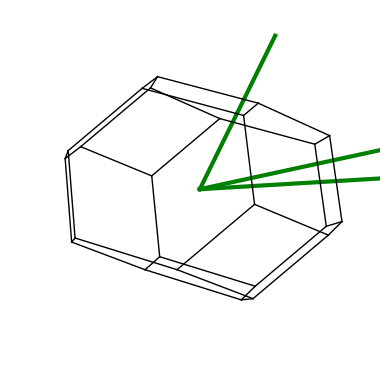

-0.000000 1.308457 1.178667
1.749445 -0.000000 1.178667
1.749445 1.308457 0.000000


In [15]:
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.electronic_structure.plotter import plot_brillouin_zone

# Trouver la maille primitive correcte
sga = SpacegroupAnalyzer(structure)
primitive_structure = sga.get_primitive_standard_structure()

# Lattice réciproque de la primitive
reciprocal_lattice = primitive_structure.lattice.reciprocal_lattice

# Plot correct de la BZ
plot_brillouin_zone(reciprocal_lattice)
print(reciprocal_lattice)

In [16]:
from pymatgen.symmetry.bandstructure import HighSymmKpath

# Générer le chemin de haute symétrie
kpath = HighSymmKpath(primitive_structure)

# Points de haute symétrie
print("Points k :")
for label, coords in kpath.kpath["kpoints"].items():
    print(label, coords)

# Chemin entre les points
print("\nChemin k :")
for segment in kpath.kpath["path"]:
    print(" -> ".join(segment))

Points k :
\Gamma [0. 0. 0.]
L [-0.31634378  0.31634378  0.41061726]
L_1 [ 0.31634378 -0.31634378  0.58938274]
L_2 [ 0.41061726  0.58938274 -0.31634378]
R [0.  0.5 0. ]
S [0.5 0.  0. ]
T [0.  0.  0.5]
W [0.25 0.25 0.25]
X [-0.36348052  0.36348052  0.36348052]
X_1 [ 0.36348052  0.63651948 -0.36348052]
Y [ 0.45286326 -0.45286326  0.45286326]
Y_1 [ 0.54713674  0.45286326 -0.45286326]
Z [ 0.5  0.5 -0.5]

Chemin k :
\Gamma -> X -> L -> T -> W -> R -> X_1 -> Z -> \Gamma -> Y -> S -> W
L_1 -> Y
Y_1 -> Z


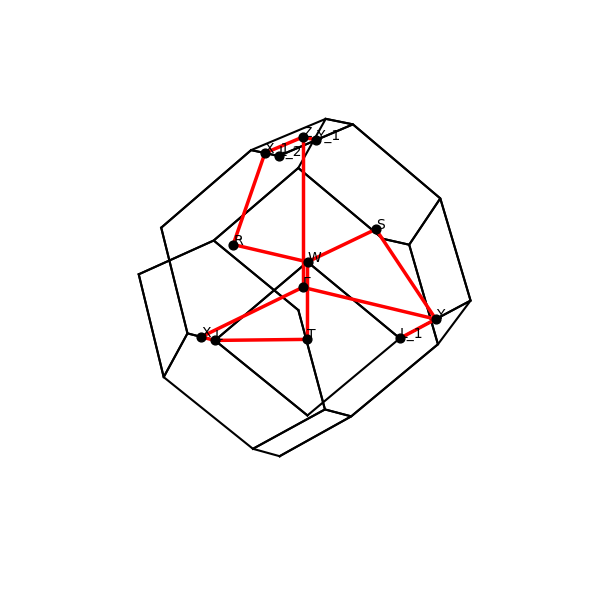

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi

from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.symmetry.bandstructure import HighSymmKpath

# ===== Structure primitive =====
sga = SpacegroupAnalyzer(structure)
primitive_structure = sga.get_primitive_standard_structure()

# ===== Réseau réciproque =====
rec_lattice = primitive_structure.lattice.reciprocal_lattice

# ===== Générer points du réseau réciproque autour de Gamma =====
points = []
for i in [-1, 0, 1]:
    for j in [-1, 0, 1]:
        for k in [-1, 0, 1]:
            vec = i*rec_lattice.matrix[0] + j*rec_lattice.matrix[1] + k*rec_lattice.matrix[2]
            points.append(vec)

points = np.array(points)

# ===== Wigner-Seitz (BZ) via Voronoi =====
vor = Voronoi(points)

# cellule autour de Gamma (index du point central)
center_index = 13  # (0,0,0)
region = vor.regions[vor.point_region[center_index]]
vertices = vor.vertices[region]

# ===== K-path =====
kpath = HighSymmKpath(primitive_structure)
kpoints = kpath.kpath["kpoints"]
path = kpath.kpath["path"]

kpoints_cart = {
    label: rec_lattice.get_cartesian_coords(coords)
    for label, coords in kpoints.items()
}

# ===== FIGURE =====
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

# ===== Dessiner UNIQUEMENT la bonne cellule =====
for ridge_points, ridge_vertices in zip(vor.ridge_points, vor.ridge_vertices):

    # garder seulement les arêtes liées au point central (Gamma)
    if center_index not in ridge_points:
        continue

    if -1 in ridge_vertices:
        continue

    pts = vor.vertices[ridge_vertices]

    ax.plot(pts[:,0], pts[:,1], pts[:,2],
            color='black',
            linewidth=1.5)

# ===== Chemin k =====
for segment in path:
    for i in range(len(segment)-1):
        p1 = kpoints_cart[segment[i]]
        p2 = kpoints_cart[segment[i+1]]

        ax.plot(
            [p1[0], p2[0]],
            [p1[1], p2[1]],
            [p1[2], p2[2]],
            color='red',
            linewidth=2.5
        )

# ===== Points =====
for label, coord in kpoints_cart.items():
    label_display = label.replace("\\Gamma", "Γ")

    ax.scatter(*coord, color='black', s=40)
    ax.text(*coord, label_display, fontsize=10)

# ===== Mise à l’échelle propre =====
all_pts = np.vstack(list(kpoints_cart.values()))
max_range = np.abs(all_pts).max()

ax.set_xlim([-max_range, max_range])
ax.set_ylim([-max_range, max_range])
ax.set_zlim([-max_range, max_range])

ax.set_box_aspect([1,1,1])
ax.set_axis_off()

ax.view_init(elev=20, azim=35)

plt.tight_layout()
plt.show()

## 6. Diffractogramme (Cu Kα, λ=1.54060 Å)

DiffractionPattern
$2\Theta$: [24.93668412 29.97560206 31.070298   33.59645178 37.42575522 46.41022882
 48.67115856 50.80235573 51.16373032 55.06230871 57.39993799 57.84921321
 60.32647182 62.29282292 63.58831949 64.77722301 70.62059682 70.95620554
 73.87264791 74.98366221 78.18907382 79.14309686 79.83019358 80.73689518
 82.5169365  82.70057061 82.76359672 83.0773306  87.54674448 89.4544456 ]
Intensity: [7.31223152e+01 1.00000000e+02 4.15333972e+00 8.93469134e+00
 3.92693826e+00 5.63457710e+01 2.32573306e-02 1.61720309e+01
 5.27073402e+00 6.03417842e+00 6.46680569e+00 5.82435484e+00
 4.30758719e+00 7.37347802e-01 1.06978099e+01 1.69686151e+00
 4.83885914e+00 2.79086026e-01 9.36650990e-02 3.05416545e+00
 3.48982458e+00 1.79629960e-02 1.48960363e-01 1.00611628e+00
 2.49280588e+00 3.03921440e+00 6.84393121e-01 5.00018989e-03
 3.63833971e+00 4.97308384e+00]

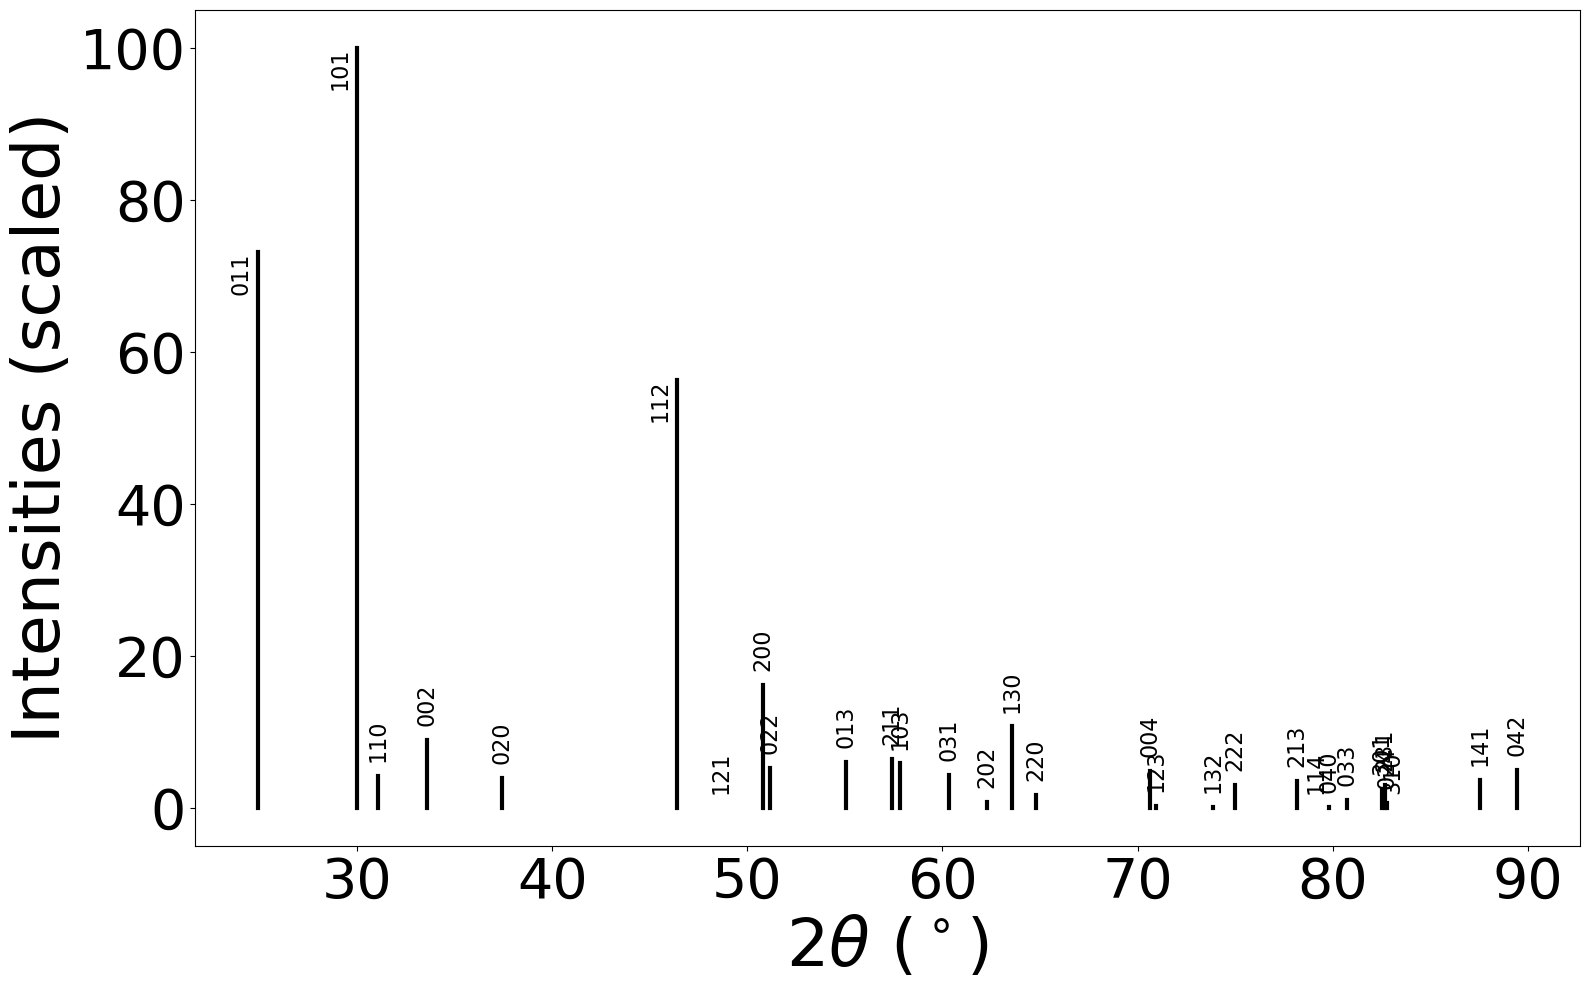

In [10]:
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.analysis.diffraction.xrd import XRDCalculator

conv_structure = SpacegroupAnalyzer(structure).get_conventional_standard_structure()

xrd = XRDCalculator(wavelength = 1.54060)
xrd.get_plot(conv_structure)
pattern = xrd.get_pattern(conv_structure)

#Il faut pas oublier le graphs avec les trois pics ;) 
pattern

In [11]:
for i in range(3):
    theta2 = pattern.x[i]
    intensité = pattern.y[i]
    indices_hkl = pattern.hkls[i][0].get("hkl")
    multiplicité = pattern.hkls[i][0].get("multiplicity")
    print("Pic numéro " + str(i+1) +":\n")
    print("- L'angle 2θ vaut: " + str(theta2) +"°\n")
    print("- L'intensité relative de ce pic (sur une échelle de 0 à 100) est de: " +str(intensité) +"\n")
    print("- Les indices (h,k,l) sont " + str(indices_hkl) +"  et de multiplicité " + str(multiplicité) +"\n\n")

Pic numéro 1:

- L'angle 2θ vaut: 24.93668411519322°

- L'intensité relative de ce pic (sur une échelle de 0 à 100) est de: 73.12231519055776

- Les indices (h,k,l) sont (0, 1, 1)  et de multiplicité 4


Pic numéro 2:

- L'angle 2θ vaut: 29.975602060777423°

- L'intensité relative de ce pic (sur une échelle de 0 à 100) est de: 99.99999999999999

- Les indices (h,k,l) sont (1, 0, 1)  et de multiplicité 4


Pic numéro 3:

- L'angle 2θ vaut: 31.07029799985703°

- L'intensité relative de ce pic (sur une échelle de 0 à 100) est de: 4.153339721278245

- Les indices (h,k,l) sont (1, 1, 0)  et de multiplicité 4




## 7. Structure de bandes électroniques

In [12]:
# Télécharger la structure de bandes
from mp_api.client import MPRester
from pymatgen.io.cif import CifWriter
from matplotlib import pyplot as plt 
from tabulate import tabulate
from pymatgen.electronic_structure import bandstructure
from pymatgen.electronic_structure import plotter
import numpy as np

m = MPRester("PXBFSqNjWuCbMDn152B5RsMt61dfXOLI")
bandstructure = m.get_bandstructure_by_material_id("mp-1378")

Retrieving ElectronicStructureDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

In [13]:
#initialisation des données et variables utiles par la suite
plot = plotter.BSPlotter(bandstructure)
# crée un dictionnaire qui contient ce que je veux
data = plot.bs_plot_data()
zero_energy = data.get('zero_energy')
distance = data.get('ticks').get('distance')
labels = data.get('ticks').get('label')
distances = data.get('distances')
energy = data.get('energy')
bandgap = bandstructure.get_band_gap()
vbmData = bandstructure.get_vbm()
cbmData = bandstructure.get_cbm()


------------------------------------  ---------
Énergie de la bande interdite :       3.2727 eV
Bande interdite directe ?             False
Transition dans la bande interdite :  W-\Gamma
Maximum de la dernière bande de valence : 

------------------------------  ---------------
Bande(s) contenant le VBM :     6
Énergie du VBM :                -0.8681 eV
(sur le graphe MP (E-Efermi) :  -0.11122747 eV)
Minimum de la première bande de conduction : 

------------------------------  ----------------------
Bande(s) contenant le CBM :     7
Énergie du CBM :                2.4046 eV
(sur le graphe MP (E-Efermi) :  3.1614725299999997 eV)


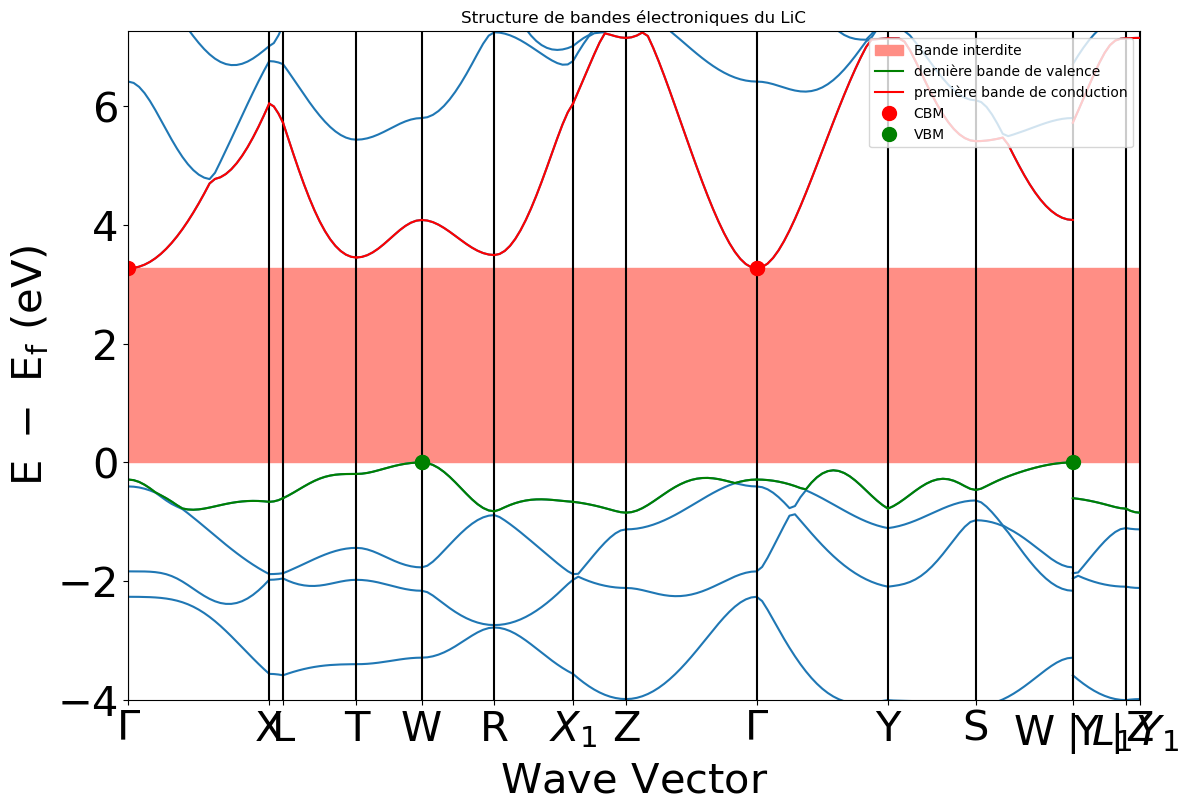

In [14]:
#plot de la structure de bandes

# on remarque que les énergies sont données par rapport à l'énergie de Fermi, d'où le zéro à 0 eV.
# Cela explique aussi pourquoi CBM et VBM sont à des valeurs différentes de sur le graphe , 
# alors qu'elles sont à des énergies positives et négatives respectivement par rapport à l'énergie de Fermi.
# energy est donc : {'1': [segment0, segment1, ..., segment12]}
# Chaque segment est lui-même une liste ou un array


vbm_idx = list(vbmData.get('band_index').values())[0][0]
cbm_idx = list(cbmData.get('band_index').values())[0][0]

plot.get_plot()
plt.fill_between(np.linspace(distance[0],distance[-1],500),
                 0, bandgap.get('energy'), color="#FF8E85", label = "Bande interdite")
#plot la derniere bande de valence en vert et la premiere bande de conduction en rouge
for i in range(len(distances)):
    plt.plot(distances[i], energy['1'][i][vbm_idx], 'g', label = "dernière bande de valence" if i == 0 else "")
    plt.plot(distances[i], energy['1'][i][cbm_idx], 'r', label = "première bande de conduction" if i == 0 else "")
#plot les points du VBM en vert et du CBM en rouge
cbms = data.get('cbm')
for i in range(len(cbms)):
    (a, b) = cbms[i]
    plt.plot(a, b, 'or', markersize=10, label = "CBM" if i == 0 else "")

vbms = data.get('vbm')
for i in range(len(vbms)):
    (a, b) = vbms[i]
    plt.plot(a, b, 'og', markersize=10, label = "VBM" if i == 0 else "")
#legende
plt.legend(loc = "upper right")
plt.title("Structure de bandes électroniques du LiC")

print(tabulate([["Énergie de la bande interdite : ",str(bandgap.get('energy'))+" eV"],
	            ["Bande interdite directe ? ",str(bandgap.get('direct'))],
	            ["Transition dans la bande interdite : ",str(bandgap.get('transition'))]],
	            headers=["",""]))
print("Maximum de la dernière bande de valence : ")
print(tabulate([["Bande(s) contenant le VBM : ",str(vbm_idx)],
	            ["Énergie du VBM : ",str(vbmData.get('energy'))+" eV"],
	            ["(sur le graphe MP (E-Efermi) : ",str(vbmData.get('energy')-bandstructure.efermi)+" eV)"]],
	            headers=["",""]))
print("Minimum de la première bande de conduction : ")
print(tabulate([["Bande(s) contenant le CBM : ",str(cbm_idx)],
	            ["Énergie du CBM : ",str(cbmData.get('energy'))+" eV"],
	            ["(sur le graphe MP (E-Efermi) : ",str(cbmData.get('energy')-bandstructure.efermi)+" eV)"]],
	            headers=["",""]))

Dans un cristal, les électrons peuvent prendre des valeurs d'énergie définies dans des intervalles précis. Ces intervalles représentent les bandes d'énergie. La zone du bas représente la bande de valence tandis que la zone du haut représente la bande de conduction. Ces énergies sont des fonctions du vecteur d'onde k (= Wave Vector), vecteur de l'espace réciproque. De par le caractère périodique des matériaux cristallins, il est possible de décrire l'entièreté du comportement des électrons en se limitant à une zone précise, la zone de Brillouin (cf. cours 4). Cette zone représente la maille du cristal dans le réseau réciproque. Les points critiques de la zone de Brillouin sont des points de haute symmétrie, et représentent toujours de maximas/ minimas locaux d'énergie ( lien avec les plans de Bragg, cf. cours 4). Ces points se trouvent pour la plupart à la surface de la zone de Brillouin, mis à part $\Gamma$ qui représente le centre de la zone de Brillouin

La zone séparant la bande de valence de la bande de conduction s'appelle la bande interdite. En fonction de la valeur de celle-ci, les électrons du cristal peuvent ou non passer de la bande de valence à la bande de conduction, et ce en absorbant une énergie supérieure à la bande interdite. Cela déterminent 3 différentes classes de matériau:
- les métaux ($E_{gap}$ = 0 eV) ne possèdent pas de bande interdite. Les électrons peuvent donc passer librement de la bande de valence à la bande de conduction.
- les isolants ($E_{gap}$ > 10 eV) possèdent une bande interdite très grande, empêchant tout passage de la bande de valence à la bande de conduction.
-  les semi-conducteurs ($E_{gap}$ < 2-3 eV) possèdent une bande interdite de plus faible intensité que les isolants. Lorsque nous nous trouvons à T= 0K, les électrons se trouvent tous dans la bande de valence. Cependant, en augmentant la température, certains électrons peuvent passer outre la bande interdite.
 
Ici notre matériau possède une bande interdite = 3.27 eV, il est donc un faible semi-conducteur.

 Le sommet de la bande de valence et le minimum de la bande de conduction ne se situent pas au même point dans l’espace réciproque, la bande interdite est donc indirecte.

## 8. Analyse de la structure de bandes: dispersions

In [ ]:
#calcule la pente sur l'intervalle (x,y)
#renvoit un tableau pour un affichage pratique des flèches : 
#    pour chaque intervalle entre 2 kpoints : [pente,x_0,y_0,dx,dy]
def slope(x,y):
	return np.array([abs((y[-1]-y[0])/(x[-1]-x[0])),x[0],y[0],x[-1]-x[0],y[-1]-y[0]])

#calcule la dispersions maximale et minimale de la bande y
#retourne : s=tableau des résultats retournés par slope pour chaque intervalle de kpoints
#           l'indice de la pente maximale dans s
#           l'indice de la pente minimale dans s
def computeDispersions_filtered(y, emin=-1.0, emax=1.0):
    """
    Calcule les dispersions uniquement sur les segments
    où la bande reste dans la fenêtre [emin, emax] eV
    """
    slopes = []
    indices = []
    for i in range(len(distances)):
        e = energy['1'][i][y]
        # On garde le segment seulement si toute la bande
        # reste dans la fenêtre d'énergie
        if np.min(e) >= emin and np.max(e) <= emax:
            slopes.append(slope(distances[i], e))
            indices.append(i)
    
    if not slopes:
        print("Aucun segment trouvé dans la fenêtre d'énergie !")
        return None, None, None
    
    slopes = np.array(slopes).T
    # print(f"Segments retenus : {indices}")
    # for k, idx in enumerate(indices):
    #     print(f"  Segment {idx} ({labels[idx]}→{labels[idx+1]}) : pente = {slopes[0,k]:.4f} eV/Å")
    
    return (slopes, indices[np.argmax(slopes[0])], indices[np.argmin(slopes[0])])

(vbs, maxVb, minVb) = computeDispersions_filtered(vbm_idx, emin=-1.0, emax=0.1)
(cbs, maxCb, minCb) = computeDispersions_filtered(cbm_idx, emin=3.0,  emax=7.0)



In [ ]:
# affichage des endroits de dispersion maximale et minimale pour les bandes de valence et de conduction



# print("=== Bande de conduction : min/max par segment ===")
# for i in range(len(distances)):
#     e = energy['1'][i][cbm_idx]
#     print(f"  Segment {i} ({labels[i]}→{labels[i+1]}) : "
#           f"min={np.min(e):.3f} eV, max={np.max(e):.3f} eV, "
#           f"pente={abs(e[-1]-e[0])/(distances[i][-1]-distances[i][0]):.3f} eV/Å")
vbm_points = data.get('vbm')
cbm_points = data.get('cbm')
fig,ax = plt.subplots(1,1,figsize=(12,9))
for i in range(len(distance)):
    plt.axvline(distance[i],0,color="black")
    
for i in range(len(vbm_points)):
    (a,b) = vbm_points[i]
    plt.plot(a,b,'og',markersize=10)
for i in range(len(cbm_points)):
    (a,b) = cbm_points[i]
    plt.plot(a,b,'or',markersize=10)
    
for i in range(len(distances)):
    plt.plot(distances[i],energy['1'][i][vbm_idx],'b')
    plt.plot(distances[i],energy['1'][i][cbm_idx],'b')

ax.set_xticks(distance)
ax.set_xticklabels(labels)
ax.set_xlabel('Wave Vector')
ax.set_ylabel('E-Ef (eV)')

# maxVb, minVb, maxCb, minCb sont maintenant des indices de segments
# On recalcule les données de la flèche directement depuis le segment
def get_arrow(seg_idx, band_idx):
    x0 = distances[seg_idx][0]
    y0 = energy['1'][seg_idx][band_idx][0]
    dx = distances[seg_idx][-1] - x0
    dy = energy['1'][seg_idx][band_idx][-1] - y0
    return x0, y0, dx, dy

x0,y0,dx,dy = get_arrow(maxCb, cbm_idx)
plt.arrow(x0,y0,dx,dy,color='red',width=0.03,length_includes_head=True, label= "Dispersion max conduction")
x0,y0,dx,dy = get_arrow(minCb, cbm_idx)
plt.arrow(x0,y0,dx,dy,color=('red', 0.4),width=0.03,length_includes_head=True, label= "Dispersion min conduction")
x0,y0,dx,dy = get_arrow(maxVb, vbm_idx)
plt.arrow(x0,y0,dx,dy,color='green',width=0.03,length_includes_head=True, label= "Dispersion max valence")
x0,y0,dx,dy = get_arrow(minVb, vbm_idx)
plt.arrow(x0,y0,dx,dy,color=('green', 0.4),width=0.03,length_includes_head=True, label= "Dispersion min valence")

plt.text(distances[maxCb][0]+0.05, energy['1'][maxCb][cbm_idx][0]-0.15, "+", fontsize=13, fontweight='bold', color='red')
plt.text(distances[minCb][0]+0.05, energy['1'][minCb][cbm_idx][0]+0.1,  "-", fontsize=13, fontweight='bold', color='red')
plt.text(distances[maxVb][0]+0.05, energy['1'][maxVb][vbm_idx][0]+0.35, "+", fontsize=13, fontweight='bold', color='green')
plt.text(distances[minVb][0]+0.05, energy['1'][minVb][vbm_idx][0]+0.15, "-", fontsize=13, fontweight='bold', color='green')

plt.legend(loc = "upper left")
plt.show()

La dispersion dans les bandes de conduction et de valence décrit comment l’énergie des électrons varie en fonction de leur vecteur d’onde k. On la trouve en calculant la pente de E et est directement liée à la vitesse des électrons. Plus une pente est raide, plus la dispersion est élevée et plus les électrons sont mobiles. A l'inverse, plus une pente est plate plus la dispersion est petite, ce qui entraine des électrons peu mobiles. On remarque bien souvent que les électrons se trouvant dans la bande de valence sont bien moins mobiles que ceux de la bande de conduction, montrant que seuls les electrons de la bande de conduction contribuent aux propriétés électriques du matériau.

## 9. Masse effective (approximation parabolique)

Une notion souvent utilisée pour évaluer l'étude du transport des électrons est la masse effective. Plutôt que de décrire des électrons de masse fixée évoluant dans un potentiel donné, on les décrit comme des électrons libres dont la masse effective varie. Cette masse effective peut-être positive ou négative, supérieure ou inférieure à la masse réelle de l'électron.

La masse effective $m^*$ est définie par: $$m^* = \hbar^2 \left(\frac{d^2E}{dk^2}\right)^{-1}$$

Nous nous intéressons ici à la masse effective au sommet de la dernière bande de valence et au bas de la première bande de conduction. Afin de trouver ces masses effectives, nous allons donc premièrement approximer la courbe d'énergie aux points désirés en une parabole.  L'équation de la parabole est donnée par : $$ E(k) = ak^2 + bk +c$$

Grâce à cette approximation, nous savons que la dérivée seconde de E en fonction de k est égale à : $$ \frac{d^2E}{dk^2} = a$$
Enfin, nous pouvons calculer la masse effective. 

In [ ]:
# constantes importantes
hbar2 = ((6.62607004*10**(-34))/(2*np.pi))**2
electronvolt = 1.602176634*10**(-19)
angstrom = 10**(-10)

#plot de la dernière bande de valence et des VBM 
fig,ax = plt.subplots(1,1,figsize=[15,10])
for i in range(len(distance)):
    plt.axvline(distance[i],0,color="black")
for i in range(len(vbm_points)):
    (a,b) = vbm_points[i]
    plt.plot(a,b,'og',markersize=10)
for i in range(len(distances)):
    plt.plot(distances[i],energy['1'][i][vbm_idx],'b')
ax.set_xticks(distance)
ax.set_xticklabels(labels)
ax.set_xlabel('Wave Vector')
ax.set_ylabel('E-Ef (eV)')
plt.title('Dernière bande de valence')

#calcul de la parabole d'approximation aux alentours du VBM
# On cherche le segment contenant le VBM
N = 5  # nombre de points de chaque côté, ajustable

k_fit = np.concatenate([distances[3][-N:], distances[4][:N]])
e_fit = np.concatenate([energy['1'][3][vbm_idx][-N:], energy['1'][4][vbm_idx][:N]])

# Ajustement parabolique local autour du VBM
a = np.polyfit(k_fit, e_fit, 2)

print(tabulate([["Parabole d'approximation : ","y(k) = "+str(a[0])+"k\u00b2 + "+str(a[1])+"k "+str(a[2])],
                ["Dérivée seconde : ",str(2*a[0])+" eV\u212b\u00b2"],
                ["Masse effective : ",str(hbar2/(2*a[0]*electronvolt*(angstrom)**2))+" kg"]],
                headers=["",""]))
print("\n")

# Tracé uniquement sur la région locale autour du VBM
k_plot = np.linspace(distances[3][-N], distances[4][N], 1000)
plt.plot(k_plot, np.polyval(a, k_plot), 'g')

In [ ]:
# print("Tous les points CBM:")
# for i, pt in enumerate(cbm_points):
#     print(f"  cbm_points[{i}]: k={pt[0]:.4f}, E={pt[1]:.4f} eV")

#plot de la première bande de conduction et du CBM
fig,ax = plt.subplots(1,1,figsize=[15,10])
for i in range(len(distance)):
    plt.axvline(distance[i],0,color="black")
for i in range(len(cbm_points)):
    (a,b) = cbm_points[i]
    plt.plot(a,b,'or',markersize=10)
for i in range(len(distances)):
    plt.plot(distances[i],energy['1'][i][cbm_idx],'b')
ax.set_xticks(distance)
ax.set_xticklabels(labels)
ax.set_xlabel('Wave Vector')
ax.set_ylabel('E-Ef (eV)')
plt.title('Première bande de conduction')

# CBM en Γ central (k=5.6084), à la jonction des segments 7 et 8
# On prend un point dans le segment 7 (avant Γ) et un dans le segment 8 (après Γ)
ks2 = np.zeros(3)
es2 = np.zeros(3)
(ks2[1], es2[1]) = cbm_points[1]                                        # CBM en Γ
(ks2[0], es2[0]) = (distances[7][-3], energy['1'][7][cbm_idx][-3])      # point avant Γ
(ks2[2], es2[2]) = (distances[8][2],  energy['1'][8][cbm_idx][2])       # point après Γ
a2 = np.polyfit(ks2, es2, 2)

#affichage des résultats
# même calcul que pour la bande de valence, mais pour la conduction
print(tabulate([["Parabole d'approximation : ","y(k) = "+str(a2[0])+"k\u00b2 "+str(a2[1])+"k +"+str(a2[2])],
                ["Dérivée seconde : ",str(2*a2[0])+" eV\u212b\u00b2"],
                ["Masse effective : ",str(hbar2/(2*a2[0]*electronvolt*(angstrom)**2))+" kg"]],
               headers=["",""]))
print("\n")
x2 = np.linspace(distances[7][-5], distances[8][5], 1000)
plt.plot(x2, np.polyval(a2,x2), 'r')
plt.show()

## 10. Structure de bandes de phonons

In [ ]:
from phonopy import load as phonopy_load
from phonopy.phonon.band_structure import get_band_qpoints_and_path_connections
import matplotlib.pyplot as plt

# Charger le fichier (phonopy lit le .xz directement)
phonon = phonopy_load("phonopy_params (2).yaml.xz")

# Tracer automatiquement la structure de bandes
phonon.auto_band_structure(
    plot=True,
    write_yaml=False
)
plt.show()

In [ ]:
from phonopy import load as phonopy_load
import matplotlib.pyplot as plt

phonon = phonopy_load("phonopy_params (2).yaml.xz")
phonon.auto_band_structure(npoints=101)

# Correction : plot_band_structure() retourne juste un objet plt
plt_obj = phonon.plot_band_structure()

# Récupérer fig et ax depuis matplotlib directement
fig = plt.gcf()
ax = plt.gca()

# Personnalisation
ax.set_ylabel("Frequencies (THz)", fontsize=13)
ax.set_xlabel("Wave Vector", fontsize=13)
ax.set_title("Phonon Band Structure - LiC (mp-1378)", fontsize=14)
ax.set_ylim(0,15)
ax.axhline(y=0, color='k', linewidth=0.8, linestyle='--')

plt.show()

In [ ]:
from phonopy import load as phonopy_load
import matplotlib.pyplot as plt

phonon = phonopy_load("phonopy_params (2).yaml.xz")
phonon.auto_band_structure(npoints=101)
phonon.plot_band_structure()

fig = plt.gcf()

# Agrandir la figure
fig.set_size_inches(12, 7)

# Ajuster tous les axes
for ax in fig.get_axes():
    ax.set_ylim(0, 15)
    ax.set_ylabel("Frequencies (THz)", fontsize=13)
    ax.tick_params(axis='both', labelsize=11)

# Supprimer les marges et maximiser l'espace
plt.subplots_adjust(left=0.08, right=0.98, top=0.92, bottom=0.12, wspace=0.05)
fig.suptitle("Phonon Band Structure - LiC (mp-1378)", fontsize=14)

plt.savefig("phonon_LiC.png", dpi=150, bbox_inches='tight')
plt.show()

## 11. Vitesse du son (branches acoustiques)

In [ ]:
phonon = phonopy_load("phonopy_params (2).yaml.xz")
phonon.auto_band_structure(npoints=101)

# Récupérer les données brutes
bs = phonon.band_structure

# Équivalences :
distances  = bs.distances    # équivalent data['distances']
frequency  = bs.frequencies  # équivalent data['frequency']

# Labels des points de haute symétrie
labels = bs.labels
connections = bs.path_connections


In [ ]:
import numpy as np

def find_acoustic_branches(frequencies, threshold=0.5):
    frequence = []
    branche = []
    zone = []
    
    for i in range(len(frequencies)):  # boucle sur les segments
        n_branches = frequencies[i].shape[1]  # phonopy: (n_qpoints, n_branches)
        
        for j in range(n_branches):  # boucle sur les branches
            # Extraire la branche j du segment i : tous les qpoints
            freq_branch = frequencies[i][:, j]  # ← correction clé : [:, j] au lieu de [j]
            
            # Condition : fréquence quasi-nulle au début OU à la fin du segment
            if (abs(freq_branch[0]) < threshold or abs(freq_branch[-1]) < threshold) \
                and j not in branche and i not in zone:
                zone.append(i)
                branche.append(j)
                frequence.append(freq_branch)
    
    return frequence, branche, zone

acoustic_branches = find_acoustic_branches(frequency)
frequences_acoustiques, indices_branches, indices_zones = acoustic_branches

print("Branches acoustiques :", indices_branches)
print("Zones correspondantes :", indices_zones)

# Récupérer distances et fréquences pour chaque branche acoustique
q1 = distances[indices_zones[0]]
q2 = distances[indices_zones[1]]
q3 = distances[indices_zones[2]]

f1 = frequency[indices_zones[0]][:, indices_branches[0]]
f2 = frequency[indices_zones[1]][:, indices_branches[1]]
f3 = frequency[indices_zones[2]][:, indices_branches[2]]

In [ ]:
import numpy as np

def get_segment_names(labels, path_connections):
    segment_names = []
    label_idx = 0
    
    for i, connected in enumerate(path_connections):
        start = labels[label_idx]
        end   = labels[label_idx + 1]
        segment_names.append(f"{start}-{end}")
        
        if connected:
            label_idx += 1
        else:
            label_idx += 2
    
    return segment_names

def find_acoustic_branches(frequencies, distances, segment_names, threshold=0.5):
    frequence = []
    branche   = []
    zone      = []
    noms      = []

    for i in range(len(frequencies)):
        n_branches = frequencies[i].shape[1]

        for j in range(n_branches):
            freq_branch = frequencies[i][:, j]

            if (abs(freq_branch[0]) < threshold or abs(freq_branch[-1]) < threshold) \
                and j not in branche and i not in zone:
                zone.append(i)
                branche.append(j)
                frequence.append(freq_branch)
                noms.append(segment_names[i])

    return frequence, branche, zone, noms

segment_names = get_segment_names(labels, connections)

frequences_acoustiques, indices_branches, indices_zones, noms_segments = \
    find_acoustic_branches(frequency, distances, segment_names)

print("Branches acoustiques :", indices_branches)
print("Zones correspondantes :", indices_zones)
print("Ceci correspond aux bandes", ", ".join(noms_segments))


## 12. Densité d'états de phonons

In [ ]:


phonon = phonopy_load("phonopy_params (2).yaml.xz")

# Méthode tétraèdre — plus stable que la méthode gaussienne
phonon.run_mesh(
    [20, 20, 20],
    is_mesh_symmetry=False,
    with_eigenvectors=False,
    is_gamma_center=True
)

phonon.run_total_dos(
    use_tetrahedron_method=True,   # ← remplace sigma
    freq_min=0.0,
    freq_max=20.0,
    freq_pitch=0.1
)

# Récupérer les données
dos_dict        = phonon.get_total_dos_dict()
frequencies_dos = dos_dict["frequency_points"]
dos             = dos_dict["total_dos"]

# Tracer
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(frequencies_dos, dos, color='blue', linewidth=1.5)
ax.fill_between(frequencies_dos, dos, alpha=0.3, color='blue')
ax.set_xlabel("Fréquence (THz)", fontsize=13)
ax.set_ylabel("DOS (états/THz)", fontsize=13)
ax.set_title("Densité d'états des phonons - LiC (mp-1378)", fontsize=14)
ax.set_xlim(0, 20)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

## 13. Modèles de Debye et d'Einstein

### Chaleur spécifique molaire normalisée à volume constant

In [ ]:
phonon.run_mesh(
    [20, 20, 20],
    is_mesh_symmetry=False,
    with_eigenvectors=False,
    is_gamma_center=True
)
phonon.run_thermal_properties(5, 1000, 5)
thermal_dict = phonon.get_thermal_properties_dict()
temperatures = thermal_dict["temperatures"] 
heat_capacity = thermal_dict["heat_capacity"]

N_atoms = len(phonon.primitive)  # nombre d'atomes dans la maille primitive
R = 8.314  # J/mol/K
# Limite Dulong-Petit
dulong_petit = 3 * N_atoms * R  # J/mol/K

heat_capacity_normalized = heat_capacity / dulong_petit

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(temperatures, heat_capacity_normalized, color='blue', linewidth=2, label='LiC (mp-1378)')

ax.axhline(y=1, color='red', linestyle='--', 
           linewidth=1.5, label=f'Dulong-Petit = {dulong_petit:.1f} J/mol/K')

ax.set_xlabel("Température (K)", fontsize=13)
ax.set_ylabel("Capacité calorifique Cv normalisée (J/mol/K)", fontsize=13)
ax.set_title("Capacité calorifique normalisée à volume constant - LiC (mp-1378)", fontsize=14)
ax.set_xlim(0, 1000)
ax.set_ylim(bottom=0)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()



#### Modèle d'Einstein 

In [ ]:
# Ajustement moindres carrés pour ΘD et ΘE
# Implémentation à compléter

import numpy as np
import matplotlib.pyplot as plt

norm = 3 * N_atoms * 8.314  # 3 * N_atomes * R pour LiC

# Normaliser heat_capacity
heat_capacity_norm = [c / norm for c in heat_capacity]

def cv_einstein(theta_E, T):
    if T == 0:
        return 0
    x = theta_E / T
    exp_x = np.exp(x)
    if np.isinf(exp_x):   # remplace try/except
        return 0
    denom = np.expm1(x)
    return (x**2 * exp_x) / (denom**2)

def erreur_einstein(theta):
    erreur_totale = 0
    for T, c_exp in zip(temperatures, heat_capacity_norm):  # ← normalisé
        if T == 0:
            continue
        cv_th = cv_einstein(theta, T)
        erreur_totale += (cv_th - c_exp)**2
    return erreur_totale

# Recherche plus fine
theta_E_opt = min(np.linspace(1, 2000, 10000), key=erreur_einstein)
print(f"Température d'Einstein optimale : {theta_E_opt:.1f} K")

cv_einstein_curve = [cv_einstein(theta_E_opt, T) for T in temperatures]

plt.figure(figsize=(8, 5))
plt.plot(temperatures, heat_capacity_norm, 'bo', markersize=3,
         label='Phonopy', alpha=0.6)
plt.plot(temperatures, cv_einstein_curve, 'g-', linewidth=2,
         label=fr"Einstein ($\Theta_E$ = {theta_E_opt:.0f} K)")
plt.axhline(1.0, linestyle='--', color='gray', label="Dulong-Petit")
plt.xlabel("Température (K)")
plt.ylabel(r"$C_v / (3N_{at}R)$")
plt.title("Ajustement du modèle d'Einstein")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Modèle de Deybes

In [ ]:
from scipy.integrate import quad
def integrand_debye(x):
    return (x**4 * np.exp(x)) / ((np.exp(x) - 1)**2)

def cv_debye(theta_D, T):
    if T == 0:
        return 0
    integral, _ = quad(integrand_debye, 0, theta_D / T)
    return 3 * (T / theta_D)**3 * integral  # normalisé

def erreur_debye(theta):
    erreur_totale = 0

    for i in range(len(temperatures)):
        T = temperatures[i]
        c_exp = heat_capacity_norm[i]

        c_th = cv_debye(theta, T)     
        ecart = c_th - c_exp        
        erreur_totale += ecart**2     

    return erreur_totale

theta_D_opt = min(range(1, 1000), key=erreur_debye)
print("Température de Debye optimale :", theta_D_opt, "K")
cv_debye_curve = [cv_debye(theta_D_opt, T) for T in temperatures]

plt.figure(figsize=(8, 5))
plt.plot(temperatures, cv_debye_curve, label=fr"Modèle de Debye ($\Theta_D$ = {theta_D_opt} K)", color='blue')
plt.xlabel("Température (K)")
plt.ylabel(r"$C_v / (3N_{at}R)$")
plt.title("Ajustement du modèle de Debye à la chaleur spécifique")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 14. Courbes de chaleur spécifique

In [ ]:


# Tracer les trois courbes ici

plt.figure(figsize=(8, 5))
plt.plot(temperatures, cv_debye_curve, label=fr"Modèle de Debye ($\Theta_D$ = {theta_D_opt} K)", color='red')
plt.plot(temperatures, cv_einstein_curve, 'g-', linewidth=2,
         label=fr"Einstein ($\Theta_E$ = {theta_E_opt:.0f} K)")
plt.plot(temperatures, heat_capacity_norm, 'bo', markersize=3,
         label='Phonopy', alpha=0.6)
plt.xlabel("Température (K)")
plt.ylabel(r"$C_v / (3N_{at}R)$")
plt.legend()
plt.title("Comparaison des modèles de Debye et d'Einstein avec les données de Phonopy")
plt.grid(True)
plt.show()

##### Comparaison des trois densités d'états 

In [ ]:
k_B = 1.380649e-23
conv_THz = 1e-12
h_barre = 1.055e-34

freq = frequencies_dos
dens = dos

omega_e = conv_THz*k_B*theta_E_opt/h_barre
f_e = omega_e/(2*np.pi)

omega_d = conv_THz*k_B*theta_D_opt /h_barre
f_d = omega_d / (2 * np.pi)

print("\nLa fréquence de Debye vaut : ",f_e," [THz]")
print("La fréquence d'Einstein vaut : ",f_d,"[THz]")
print("-------------------------------------------------------------------------------------------------------------------")

dens_d = np.zeros(len(freq))
for i,f in enumerate(freq):
    omega = 2*np.pi*f
    if omega < omega_d:
        dens_d[i] = (9*N_atoms*(omega)**2/(omega_d**3))

plt.plot(freq, dens,color="red", label="Données")
plt.vlines(f_e, 0, 3 * N_atoms ,color="green", label = "Einstein")
plt.plot(freq, dens_d*(2*np.pi), color='blue', label="Debye")
plt.title("Comparaison des 3 densités d'états")
plt.ylabel("Densités d'états de phonons")
plt.xlabel("Fréquence [THz]")
plt.legend()
plt.grid()
plt.show()